In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path("visuals").mkdir(exist_ok=True)

In [4]:
df= pd.read_csv('diabetes.csv')

In [6]:
df.head()   

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.tail

<bound method NDFrame.tail of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [10]:
df.shape

(768, 9)

In [11]:
df.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [13]:
df.isnull().sum()  

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627  

In [15]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [19]:
print(df['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [20]:
print(df.corr().round(2))

                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                      1.00     0.13           0.14          -0.08   
Glucose                          0.13     1.00           0.15           0.06   
BloodPressure                    0.14     0.15           1.00           0.21   
SkinThickness                   -0.08     0.06           0.21           1.00   
Insulin                         -0.07     0.33           0.09           0.44   
BMI                              0.02     0.22           0.28           0.39   
DiabetesPedigreeFunction        -0.03     0.14           0.04           0.18   
Age                              0.54     0.26           0.24          -0.11   
Outcome                          0.22     0.47           0.07           0.07   

                          Insulin   BMI  DiabetesPedigreeFunction   Age  \
Pregnancies                 -0.07  0.02                     -0.03  0.54   
Glucose                      0.33  0.22          

In [21]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print("Zero counts (actually missing):")
print((df[zero_cols] == 0).sum())

Zero counts (actually missing):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [22]:
print(df.groupby('Outcome').mean().round(2))

         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Outcome                                                                       
0               3.30   109.98          68.18          19.66    68.79  30.30   
1               4.87   141.26          70.82          22.16   100.34  35.14   

         DiabetesPedigreeFunction    Age  
Outcome                                   
0                            0.43  31.19  
1                            0.55  37.07  


In [23]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,100],
                         labels=['20s','30s','40s','50+'])
print(df.groupby('AgeGroup')['Outcome'].mean().round(3))

AgeGroup
20s    0.216
30s    0.484
40s    0.566
50+    0.469
Name: Outcome, dtype: float64


/var/folders/p5/l3z7p13d12ddb_rnbrv0q5r40000gn/T/ipykernel_30613/806848786.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Outcome'].mean().round(3))


In [27]:
df_cleaned = df.copy()

In [28]:
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_cleaned[zero_cols] = df_cleaned[zero_cols].replace(0, np.nan)


In [29]:
for col in zero_cols:
    median = df_cleaned[col].median()
    df_cleaned[col].fillna(median, inplace=True)
print(df_cleaned.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
AgeGroup                    0
dtype: int64


/var/folders/p5/l3z7p13d12ddb_rnbrv0q5r40000gn/T/ipykernel_30613/141138934.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median, inplace=True)


In [30]:
#Feature Engineering 
# BMI category
df_cleaned['BMI_Category'] = pd.cut(df_cleaned['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight','Normal','Overweight','Obese'])
# Glucose level category
df_cleaned['Glucose_Category'] = pd.cut(df_cleaned['Glucose'],
    bins=[0, 70, 100, 125, 300],
    labels=['Low','Normal','Pre-diabetic','Diabetic range'])
# Age group
df_cleaned['AgeGroup'] = pd.cut(df_cleaned['Age'],
    bins=[20, 30, 40, 50, 100],
    labels=['20s','30s','40s','50+'])
# Risk score: combine high glucose + high BMI + older age
df_cleaned['RiskScore'] = (
    (df_cleaned['Glucose'] > 140).astype(int) +
    (df_cleaned['BMI'] > 30).astype(int) +
    (df_cleaned['Age'] > 40).astype(int)
)
print(df_cleaned.head())



   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome AgeGroup BMI_Category  \
0                     0.627   50        1      40s        Obese   
1                     0.351   31        0      30s   Overweight   
2                     0.672   32        1      30s       Normal   
3                     0.167   21        0      20s   Overweight   
4                     2.288   33        1      30s        Obese   

  Glucose_Category  RiskScore  
0   Diabetic range          3  
1           Normal          0  
2   Diabetic range          1  
3           Normal          0  
4   

In [32]:
df_cleaned.to_csv("data/diabetes_clean.csv", index=False)

In [33]:
#Visualization
sns.set_theme(style="whitegrid", palette="muted")
df_clean = pd.read_csv("data/diabetes_clean.csv")


/var/folders/p5/l3z7p13d12ddb_rnbrv0q5r40000gn/T/ipykernel_30613/756552765.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Outcome', y='BMI',
/var/folders/p5/l3z7p13d12ddb_rnbrv0q5r40000gn/T/ipykernel_30613/756552765.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No diabetes','Diabetes'])


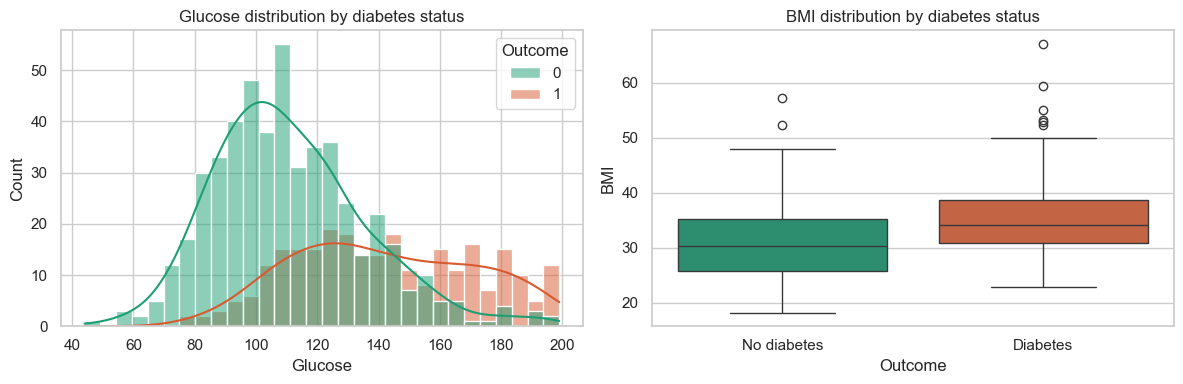

In [39]:
# --- Plot 1: Distribution of Glucose by Outcome ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_clean, x='Glucose', hue='Outcome',
             bins=30, kde=True, ax=axes[0], palette=['#1D9E75','#D85A30'])
axes[0].set_title('Glucose distribution by diabetes status')
sns.boxplot(data=df_clean, x='Outcome', y='BMI',
            ax=axes[1], palette=['#1D9E75','#D85A30'])
axes[1].set_title('BMI distribution by diabetes status')
axes[1].set_xticklabels(['No diabetes','Diabetes'])
plt.tight_layout()
plt.savefig("visuals/glucose_bmi.png", dpi=150, bbox_inches='tight')
plt.show()